In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
%matplotlib inline

In [3]:
import sys
sys.path.insert(0,"../python")

In [4]:
from load_sim_tigresspp import LoadSimTIGRESSPP

In [5]:
sim = LoadSimTIGRESSPP("/scratch/gpfs/changgoo/tigress_classic/crmhd-8pc-b1-mhdbc_diode-crbc_lngrad_out-sigma_selfc-Vmax2-rst/")

In [6]:
from plot_slices import plot_acoustic

[1777054317.406682] [stellar-vis1:3755006:0]        ib_iface.c:1231 UCX  ERROR mlx5_0: ibv_create_cq(cqe=4096) failed: Cannot allocate memory : Please set max locked memory (ulimit -l) to 'unlimited' (current: 64 kbytes)
[1777054317.406697] [stellar-vis1:3755006:0]      ucp_worker.c:1415 UCX  ERROR uct_iface_open(rc_verbs/mlx5_0:1) failed: Input/output error


[stellar-vis1.princeton.edu:3755006] pml_ucx.c:309  Error: Failed to create UCP worker


In [7]:
beta = np.logspace(-2,2)
gam = 5/3.
gm1 = gam-1
f1 = (1-0.5/np.sqrt(gam*beta))*(1+gm1/np.sqrt(gam*beta))
f2 = (1+0.5/np.sqrt(gam*beta))*(1-gm1/np.sqrt(gam*beta))

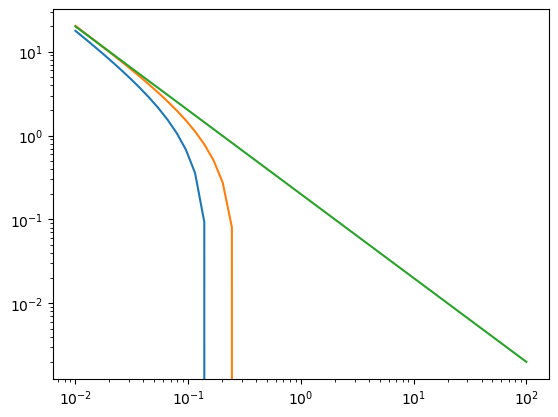

In [8]:
gmc=4/3.
plt.plot(beta,-f1)
plt.plot(beta,-f2)
plt.plot(beta,gm1*0.5/(gam*beta))
plt.xscale("log")
plt.yscale("log")

In [17]:
sim.zprof = sim.load_zprof()

In [30]:
np.sqrt(5/3.*1e4*au.K*ac.k_B/ac.m_p).to("km/s")

<Quantity 11.72916575 km / s>

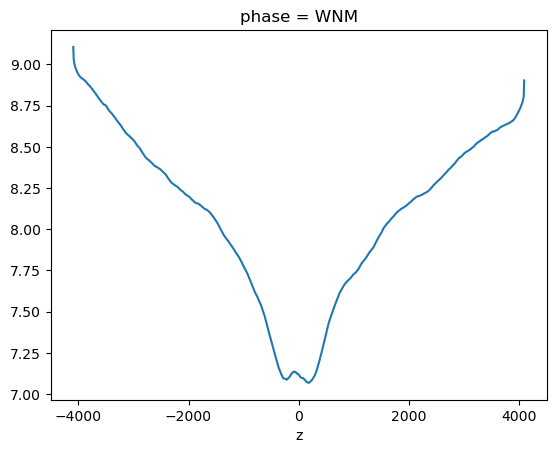

In [28]:
cs = (sim.zprof["cs"].sel(phase="WNM")).sel(time=slice(200,500)).sum(dim="vz_dir").mean(dim="time")
area = (sim.zprof["area"].sel(phase="WNM")).sel(time=slice(200,500)).sum(dim="vz_dir").mean(dim="time")
(cs/area).plot()

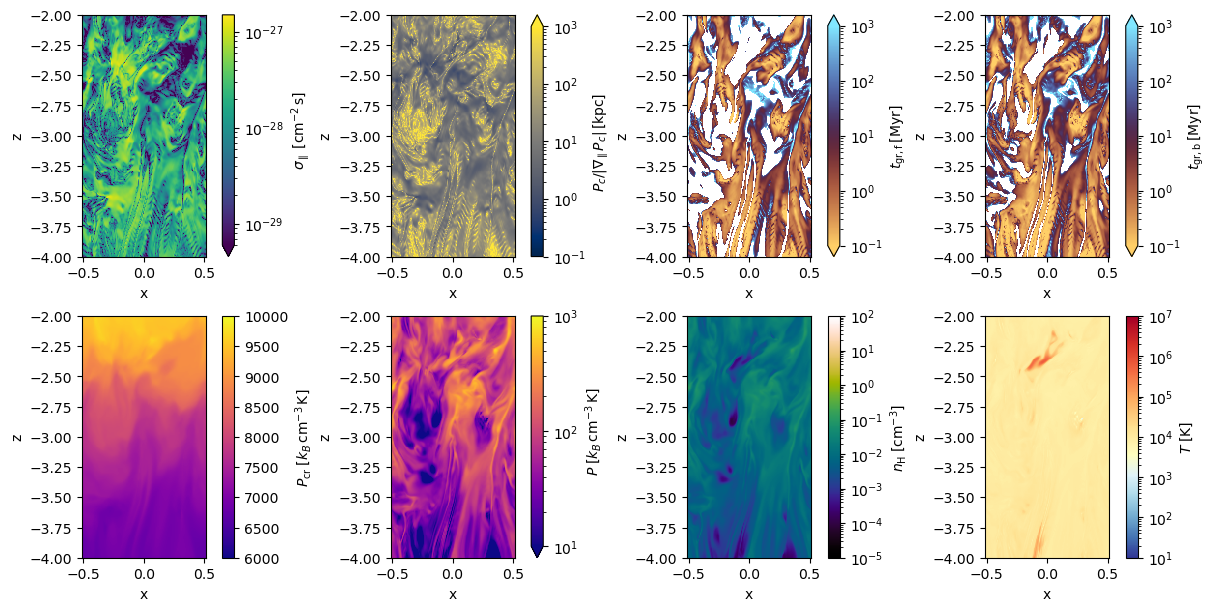

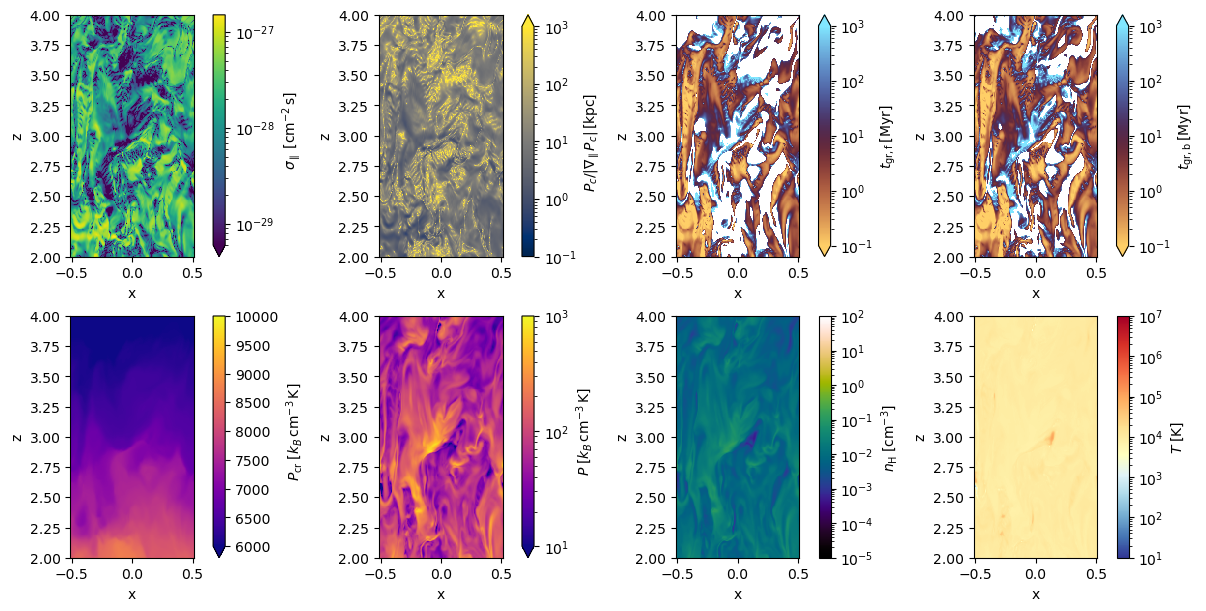

In [62]:
num = 398
# load slices
slc = sim.get_slice(num,"allslc.y", slc_kwargs=dict(y=0, method="nearest"))
crslc = sim.get_crslice(num,"crslc.y", slc_kwargs=dict(y=0, method="nearest"))

# adiabatic index
gmc= 4/3.
gam= 5/3.
gm1= gam-1

# derived quantities
sigma_para = sim.dfi["sigma_para"]["func"](slc,sim.u)
nH = sim.dfi["nH"]["func"](slc,sim.u)
T = sim.dfi["T"]["func"](slc,sim.u)
Pcr = sim.dfi["pok_cr"]["func"](slc,sim.u)
Pth = sim.dfi["pok"]["func"](slc,sim.u)
gradPcr = crslc["gradPcr"]
lcr = np.abs(crslc["lcr"])/1.e3
vA = sim.dfi["vAmag"]["func"](slc,sim.u)
vAi = sim.dfi["VAi_mag"]["func"](slc,sim.u)
vAiz = sim.dfi["VAi3"]["func"](slc,sim.u)
vz = sim.dfi["vz"]["func"](slc,sim.u)
cs = sim.dfi["cs"]["func"](slc,sim.u)
a_s = np.sqrt(gam)*cs
beta = vA/a_s
betai = vAi/(a_s)
alpha = Pcr/Pth

# acoustic instability growth time
grate0 = 0.5*gmc*alpha*(cs*1.e5)**2*sigma_para
def theta(v_s, a_s, forward=True):
    if forward:
        return -(1 - 0.5*v_s/a_s)*(1+gm1*v_s/a_s)
    else:
        return -(1 + 0.5*v_s/a_s)*(1-gm1*v_s/a_s)
tgri_f = au.s.to("Myr")/(grate0*theta(vAi, a_s))
tgri_b = au.s.to("Myr")/(grate0*theta(vAi, a_s, forward=False))

sim.dfi["pok_cr"]["imshow_args"]["norm"]=Normalize(6.e3,1.e4)
sim.dfi["pok"]["imshow_args"]["norm"]=LogNorm(10,1.e3)
kwargs = [sim.dfi["sigma_para"]["imshow_args"],
        dict(cmap=plt.cm.cividis,norm=LogNorm(0.1,1.e3),cbar_kwargs=dict(label=r"$P_c/|\nabla_\parallel  P_c|\,[{\rm kpc}]$")),
        dict(cmap=plt.cm.managua,norm=LogNorm(0.1,1000),cbar_kwargs=dict(label=r"$t_{\rm gr,f}\,[{\rm Myr}]$")),
        dict(cmap=plt.cm.managua,norm=LogNorm(0.1,1000),cbar_kwargs=dict(label=r"$t_{\rm gr,b}\,[{\rm Myr}]$")),
        # dict(cmap=plt.cm.bwr,norm=LogNorm(0.1,10),cbar_kwargs=dict(label=r"$v_{A,i}/a_s$")),
        sim.dfi["pok_cr"]["imshow_args"],
        sim.dfi["pok"]["imshow_args"],
        # dict(cmap=plt.cm.berlin,norm=LogNorm(10,1000),cbar_kwargs=dict(label=r"$\alpha\equiv P_c/P_g$")),
          sim.dfi["nH"]["imshow_args"],
          sim.dfi["T"]["imshow_args"],
        ]
data = [sigma_para, lcr, tgri_f, tgri_b,
        Pcr, Pth, #alpha,
        nH, T
        ]
for zslice in [slice(-4000,-2000),slice(2000,4000)]:
    fig,axes = plt.subplots(2,4,figsize=(12,6),constrained_layout=True)
    for ax, d, kw in zip(axes.flat,data,kwargs):
        d_=d.sel(z=zslice)
        d_=d_.assign_coords(z=d_.z/1.e3,x=d_.x/1.e3)
        plt.sca(ax)
        d_.plot(**kw)
        ax.set_aspect("equal")
        # ax.axis("off")
        ax.set_title("")
    # axes.flat[0].annotate(f"t={slc.attrs['time']*sim.u.Myr:.2f} Myr,"
    #                       f" z={zslice.start//1.e3} to {zslice.stop//1.e3} kpc",
    #                       (0.1,1.01), ha="left", va="bottom",
    #                       xycoords="axes fraction", annotation_clip=False)
    # # if savefig:
    #     savdir = osp.join(sim.savdir, "cr_acoustic_plot")
    #     if not osp.exists(savdir):
    #         os.makedirs(savdir, exist_ok=True)
        zstr = int(zslice.start//1.e3)
        zend = int(zslice.stop//1.e3)
        savname = f"acoustic_z{zstr}to{zend}_{num:04d}.png"
        fig.savefig(savname, dpi=200, bbox_inches="tight")
    #     plt.close(fig)

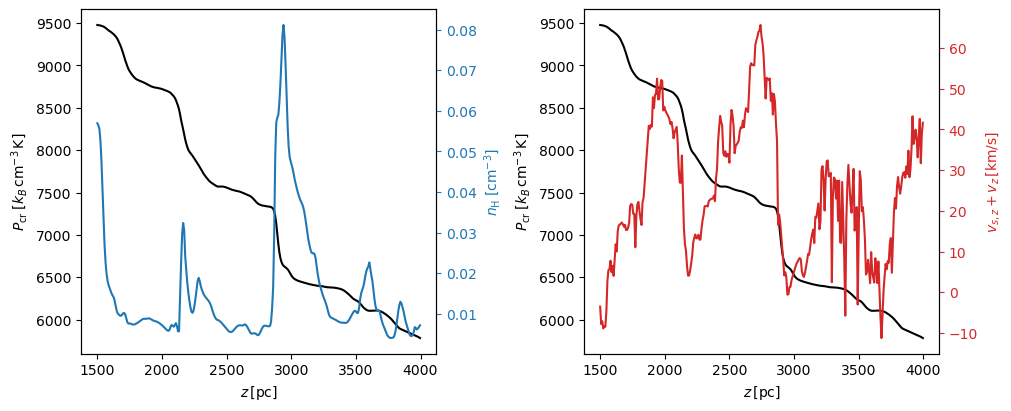

In [93]:
nH_prof = nH.sel(z=slice(1500,4000)).sel(x=slice(-128,0)).mean(dim="x")
T_prof = T.sel(z=slice(1500,4000)).sel(x=slice(-128,0)).mean(dim="x")
Pcr_prof = Pcr.sel(z=slice(1500,4000)).sel(x=slice(-128,0)).mean(dim="x")
v_prof = (vAiz+vz).sel(z=slice(1500,4000)).sel(x=slice(-128,0)).mean(dim="x")
def plot_two(d1,d2,c1="tab:red",c2="tab:blue"):
    d1.plot(color=c1)
    ax = plt.gca()
    ax.tick_params(axis='y', colors=c1)
    ax2 = ax.twinx()
    d2.plot(ax=ax2,color=c2)
    ax2.tick_params(axis='y', colors=c2)

    return ax, ax2

fig, axes = plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
l1=sim.dfi["pok_cr"]["imshow_args"]["cbar_kwargs"]["label"]
c1="k"
for ax, d2, c2, l2 in zip(axes, [nH_prof, v_prof],
                          ["tab:blue","tab:red"],
                          [sim.dfi["nH"]["imshow_args"]["cbar_kwargs"]["label"],r"$v_{s,z}+v_z\,[{\rm km/s}]$"]):
    plt.sca(ax)
    ax1, ax2 = plot_two(Pcr_prof,d2,c1=c1,c2=c2)
    ax1.set_title("")
    ax2.set_title("")
    ax1.set_xlabel(r"$z\,[{\rm pc}]$")
    ax1.set_ylabel(l1, color=c1)
    ax2.set_ylabel(l2, color=c2)
fig.savefig("bottleneck_example.png", dpi=200, bbox_inches="tight")

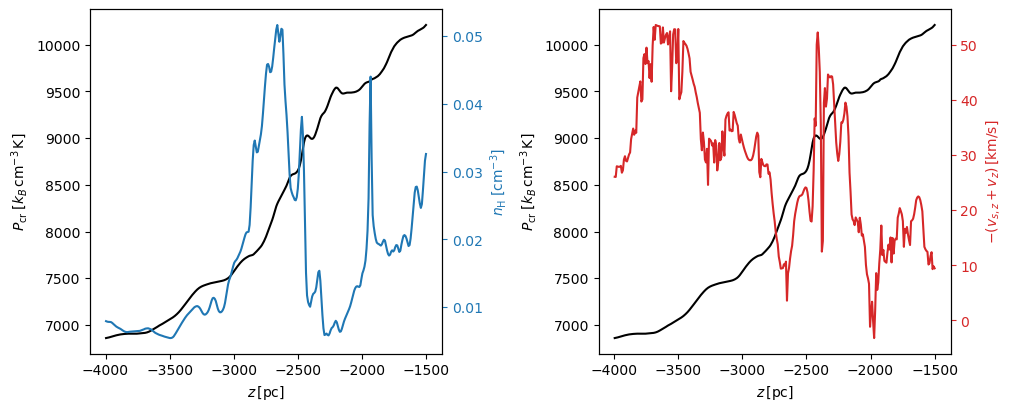

In [98]:
x0=0
dx=128
nH_prof = nH.sel(z=slice(-4000,-1500)).sel(x=slice(x0,x0+dx)).mean(dim="x")
T_prof = T.sel(z=slice(-4000,-1500)).sel(x=slice(x0,x0+dx)).mean(dim="x")
Pcr_prof = Pcr.sel(z=slice(-4000,-1500)).sel(x=slice(x0,x0+dx)).mean(dim="x")
v_prof = (vAiz+vz).sel(z=slice(-4000,-1500)).sel(x=slice(x0,x0+dx)).mean(dim="x")
def plot_two(d1,d2,c1="tab:red",c2="tab:blue"):
    d1.plot(color=c1)
    ax = plt.gca()
    ax.tick_params(axis='y', colors=c1)
    ax2 = ax.twinx()
    d2.plot(ax=ax2,color=c2)
    ax2.tick_params(axis='y', colors=c2)

    return ax, ax2

fig, axes = plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
l1=sim.dfi["pok_cr"]["imshow_args"]["cbar_kwargs"]["label"]
c1="k"
for ax, d2, c2, l2 in zip(axes, [nH_prof, -v_prof],
                          ["tab:blue","tab:red"],
                          [sim.dfi["nH"]["imshow_args"]["cbar_kwargs"]["label"],r"$-(v_{s,z}+v_z)\,[{\rm km/s}]$"]):
    plt.sca(ax)
    ax1, ax2 = plot_two(Pcr_prof,d2,c1=c1,c2=c2)
    ax1.set_title("")
    ax2.set_title("")
    ax1.set_xlabel(r"$z\,[{\rm pc}]$")
    ax1.set_ylabel(l1, color=c1)
    ax2.set_ylabel(l2, color=c2)
fig.savefig("bottleneck_example_upper.png", dpi=200, bbox_inches="tight")

In [117]:
data=sim.get_data(num=num)

In [119]:
data.load()

<xarray.Dataset> Size: 2GB
Dimensions:        (z: 1024, y: 128, x: 128)
Coordinates:
  * x              (x) float64 1kB -508.0 -500.0 -492.0 ... 492.0 500.0 508.0
  * y              (y) float64 1kB -508.0 -500.0 -492.0 ... 492.0 500.0 508.0
  * z              (z) float64 8kB -4.092e+03 -4.084e+03 ... 4.084e+03 4.092e+03
Data variables: (12/27)
    rho            (z, y, x) float32 67MB 6.417e-05 5.689e-05 ... 0.008231
    press          (z, y, x) float32 67MB 0.0449 0.06008 ... 0.4962 0.4753
    vel1           (z, y, x) float32 67MB 9.172 9.407 9.582 ... 6.555 7.646
    vel2           (z, y, x) float32 67MB -14.01 -15.07 -16.79 ... 0.7093 0.8928
    vel3           (z, y, x) float32 67MB -2.149 -0.5083 0.1981 ... 19.5 20.94
    phi            (z, y, x) float32 67MB 977.7 977.7 ... 1.011e+03 1.011e+03
    ...             ...
    0-Vd2          (z, y, x) float32 67MB 0.09673 0.1118 ... -0.4031 -0.2787
    0-Vd3          (z, y, x) float32 67MB 0.003973 0.01306 ... 0.3241 0.3108
    Bcc1           (z, y, x) float32 67MB 0.2693 0.2622 ... 0.06493 0.02783
    Bcc2           (z, y, x) float32 67MB -0.1793 -0.1664 ... 0.1535 0.1046
    Bcc3           (z, y, x) float32 67MB -0.2688 -0.2989 ... -0.1567 -0.1196
    temperature    (z, y, x) float64 134MB 5.496e+04 8.097e+04 ... 9.055e+03
Attributes: (12/16)
    Coordinates:    b'cartesian'
    DatasetNames:   [b'prim' b'B']
    MaxLevel:       0
    MeshBlockSize:  [32 32 32]
    NumCycles:      3316667
    NumMeshBlocks:  512
    ...             ...
    RootGridX3:     [-4.096e+03  4.096e+03  1.000e+00]
    Time:           398.00003
    VariableNames:  [b'rho' b'press' b'vel1' b'vel2' b'vel3' b'phi' b'phigas'...
    dx1:            8.0
    dx2:            8.0
    dx3:            8.0

In [120]:
Pcr=data["0-Ec"]/3.
Pth=data["press"]
Pkin=data["rho"]*data["vel3"]**2
Pmag=0.5*(data["Bcc1"]**2+data["Bcc2"]**2+data["Bcc3"]**2)
Pimag=0.5*(data["Bcc1"]**2+data["Bcc2"]**2+data["Bcc3"]**2) - data["Bcc3"]**2

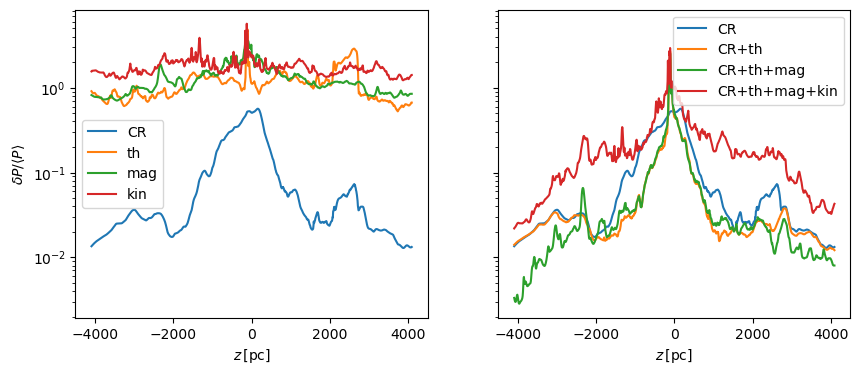

In [135]:
fig,axes = plt.subplots(1,2,figsize=(10,4),sharey=True)
plt.sca(axes[0])
for P,lab in zip([Pcr, Pth, Pmag, Pkin],
                 ["CR","th","mag","kin"]):
    (P.std(dim=["x","y"])/P.mean(dim=["x","y"])).plot(label=lab)
plt.legend()
plt.ylabel(r"$\delta P/\langle{P}\rangle$")
plt.xlabel(r"$z\,[{\rm pc}]$")
plt.yscale("log")

plt.sca(axes[1])
for P,lab in zip([Pcr, Pcr+Pth, Pcr+Pth+Pmag, Pcr+Pth+Pmag+Pkin],
                 ["CR","CR+th","CR+th+mag","CR+th+mag+kin"]):
    (P.std(dim=["x","y"])/P.mean(dim=["x","y"])).plot(label=lab)
plt.legend()
# plt.ylabel(r"$\delta P/\langle{P}\rangle$")
plt.xlabel(r"$z\,[{\rm pc}]$")
plt.yscale("log")
fig.savefig("pressure_fluctuation.png", dpi=200, bbox_inches="tight")

In [144]:
tcut = data["temperature"]<1.e4

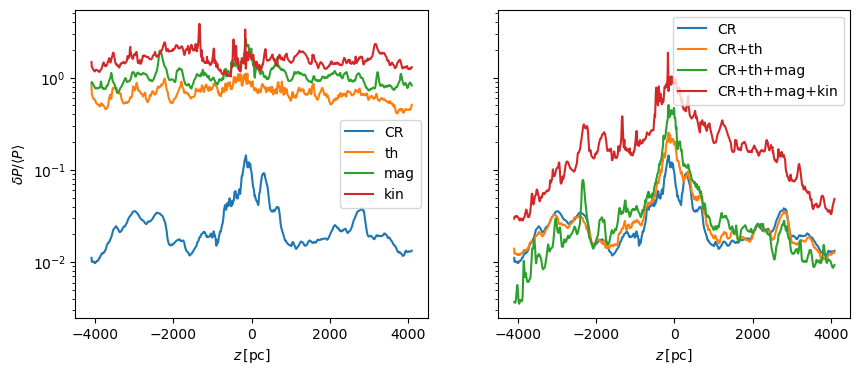

In [146]:
fig,axes = plt.subplots(1,2,figsize=(10,4),sharey=True)
plt.sca(axes[0])
for P,lab in zip([Pcr, Pth, Pmag, Pkin],
                 ["CR","th","mag","kin"]):
    (P.where(tcut).std(dim=["x","y"])/P.where(tcut).mean(dim=["x","y"])).plot(label=lab)
plt.legend()
plt.ylabel(r"$\delta P/\langle{P}\rangle$")
plt.xlabel(r"$z\,[{\rm pc}]$")
plt.yscale("log")

plt.sca(axes[1])
for P,lab in zip([Pcr, Pcr+Pth, Pcr+Pth+Pmag, Pcr+Pth+Pmag+Pkin],
                 ["CR","CR+th","CR+th+mag","CR+th+mag+kin"]):
    (P.where(tcut).std(dim=["x","y"])/P.where(tcut).mean(dim=["x","y"])).plot(label=lab)
plt.legend()
# plt.ylabel(r"$\delta P/\langle{P}\rangle$")
plt.xlabel(r"$z\,[{\rm pc}]$")
plt.yscale("log")
fig.savefig("pressure_fluctuation_warm.png", dpi=200, bbox_inches="tight")

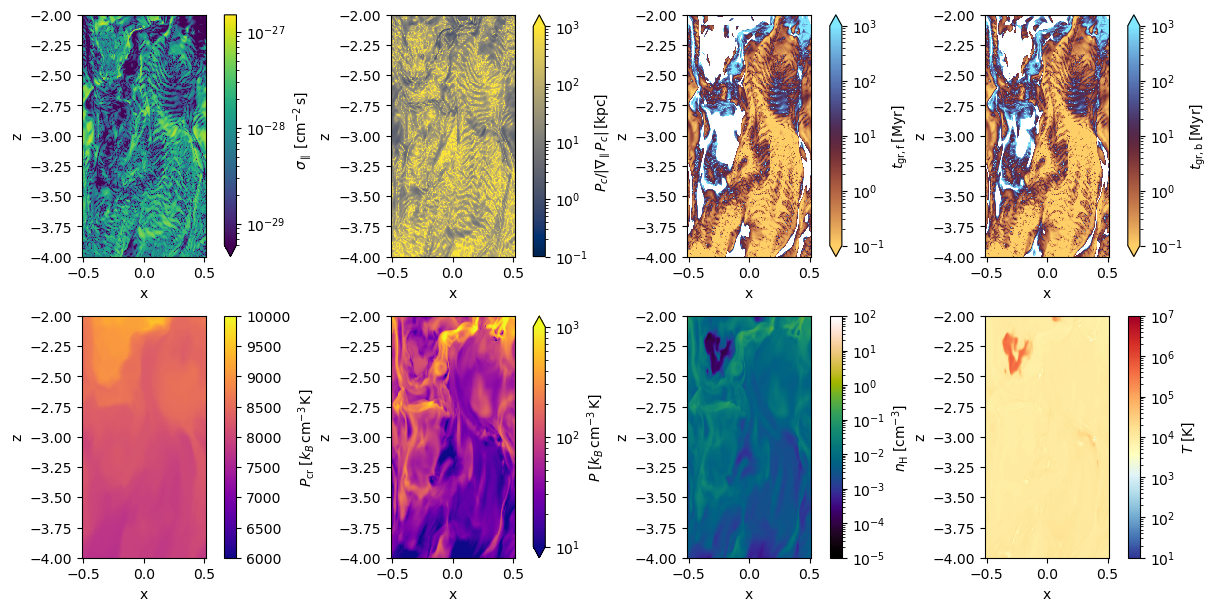

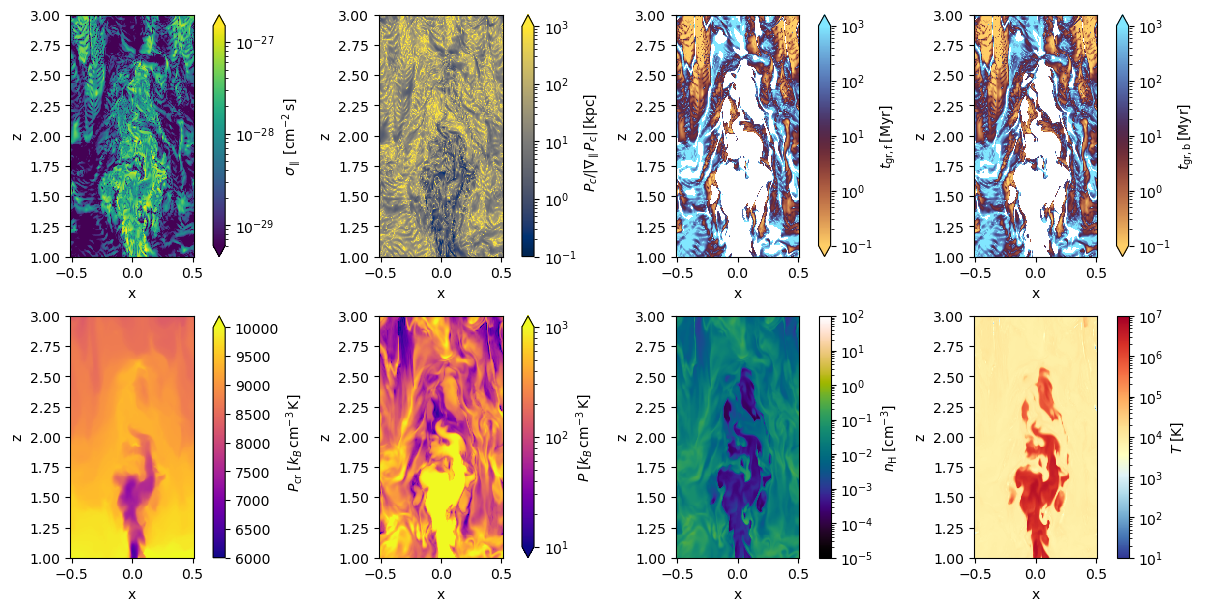

In [152]:
num = 365
# load slices
slc = sim.get_slice(num,"allslc.y", slc_kwargs=dict(y=0, method="nearest"))
crslc = sim.get_crslice(num,"crslc.y", slc_kwargs=dict(y=0, method="nearest"))

# adiabatic index
gmc= 4/3.
gam= 5/3.
gm1= gam-1

# derived quantities
sigma_para = sim.dfi["sigma_para"]["func"](slc,sim.u)
nH = sim.dfi["nH"]["func"](slc,sim.u)
T = sim.dfi["T"]["func"](slc,sim.u)
Pcr = sim.dfi["pok_cr"]["func"](slc,sim.u)
Pth = sim.dfi["pok"]["func"](slc,sim.u)
gradPcr = crslc["gradPcr"]
lcr = np.abs(crslc["lcr"])/1.e3
vA = sim.dfi["vAmag"]["func"](slc,sim.u)
vAi = sim.dfi["VAi_mag"]["func"](slc,sim.u)
vAiz = sim.dfi["VAi3"]["func"](slc,sim.u)
vz = sim.dfi["vz"]["func"](slc,sim.u)
cs = sim.dfi["cs"]["func"](slc,sim.u)
a_s = np.sqrt(gam)*cs
beta = vA/a_s
betai = vAi/(a_s)
alpha = Pcr/Pth

# acoustic instability growth time
grate0 = 0.5*gmc*alpha*(cs*1.e5)**2*sigma_para
def theta(v_s, a_s, forward=True):
    if forward:
        return -(1 - 0.5*v_s/a_s)*(1+gm1*v_s/a_s)
    else:
        return -(1 + 0.5*v_s/a_s)*(1-gm1*v_s/a_s)
tgri_f = au.s.to("Myr")/(grate0*theta(vAi, a_s))
tgri_b = au.s.to("Myr")/(grate0*theta(vAi, a_s, forward=False))

sim.dfi["pok_cr"]["imshow_args"]["norm"]=Normalize(6.e3,1.e4)
sim.dfi["pok"]["imshow_args"]["norm"]=LogNorm(10,1.e3)
kwargs = [sim.dfi["sigma_para"]["imshow_args"],
        dict(cmap=plt.cm.cividis,norm=LogNorm(0.1,1.e3),cbar_kwargs=dict(label=r"$P_c/|\nabla_\parallel  P_c|\,[{\rm kpc}]$")),
        dict(cmap=plt.cm.managua,norm=LogNorm(0.1,1000),cbar_kwargs=dict(label=r"$t_{\rm gr,f}\,[{\rm Myr}]$")),
        dict(cmap=plt.cm.managua,norm=LogNorm(0.1,1000),cbar_kwargs=dict(label=r"$t_{\rm gr,b}\,[{\rm Myr}]$")),
        # dict(cmap=plt.cm.bwr,norm=LogNorm(0.1,10),cbar_kwargs=dict(label=r"$v_{A,i}/a_s$")),
        sim.dfi["pok_cr"]["imshow_args"],
        sim.dfi["pok"]["imshow_args"],
        # dict(cmap=plt.cm.berlin,norm=LogNorm(10,1000),cbar_kwargs=dict(label=r"$\alpha\equiv P_c/P_g$")),
          sim.dfi["nH"]["imshow_args"],
          sim.dfi["T"]["imshow_args"],
        ]
data = [sigma_para, lcr, tgri_f, tgri_b,
        Pcr, Pth, #alpha,
        nH, T
        ]
for zslice in [slice(-4000,-2000),slice(1000,3000)]:
    fig,axes = plt.subplots(2,4,figsize=(12,6),constrained_layout=True)
    for ax, d, kw in zip(axes.flat,data,kwargs):
        d_=d.sel(z=zslice)
        d_=d_.assign_coords(z=d_.z/1.e3,x=d_.x/1.e3)
        plt.sca(ax)
        d_.plot(**kw)
        ax.set_aspect("equal")
        # ax.axis("off")
        ax.set_title("")
    # axes.flat[0].annotate(f"t={slc.attrs['time']*sim.u.Myr:.2f} Myr,"
    #                       f" z={zslice.start//1.e3} to {zslice.stop//1.e3} kpc",
    #                       (0.1,1.01), ha="left", va="bottom",
    #                       xycoords="axes fraction", annotation_clip=False)
    # # if savefig:
    #     savdir = osp.join(sim.savdir, "cr_acoustic_plot")
    #     if not osp.exists(savdir):
    #         os.makedirs(savdir, exist_ok=True)
        # zstr = int(zslice.start//1.e3)
        # zend = int(zslice.stop//1.e3)
        # savname = f"acoustic_z{zstr}to{zend}_{num:04d}.png"
        # fig.savefig(savname, dpi=200, bbox_inches="tight")
    #     plt.close(fig)

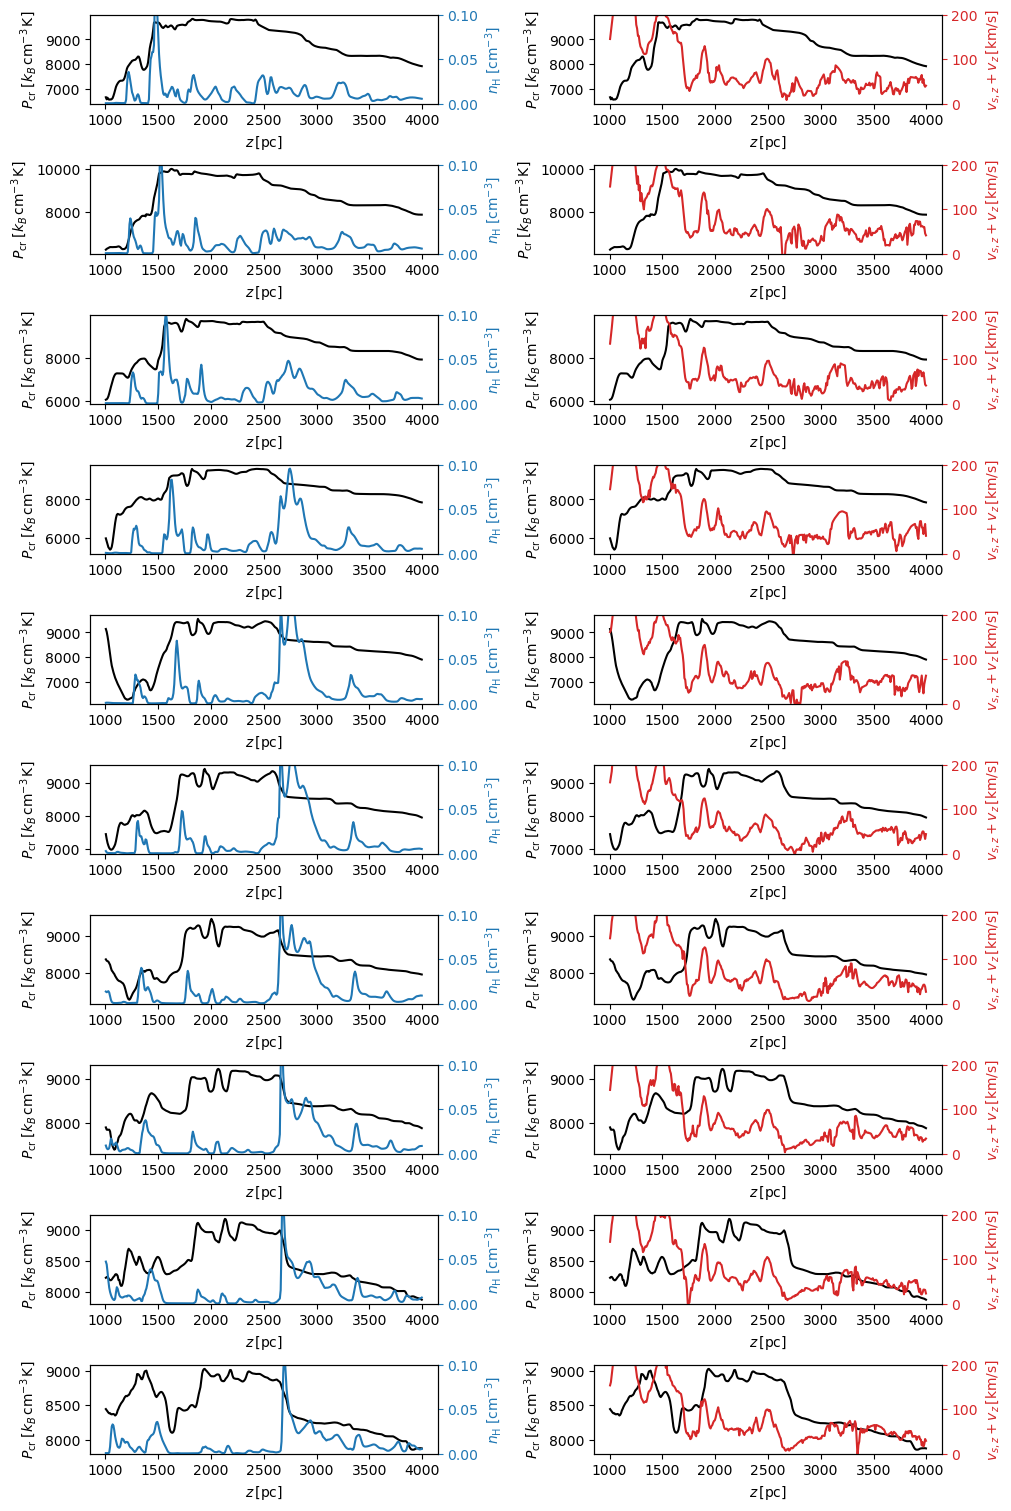

In [159]:
fig, axes_ = plt.subplots(10,2,figsize=(10,15),constrained_layout=True)
for num,axes in zip(range(360,370),axes_):
    # load slices
    slc = sim.get_slice(num,"allslc.y", slc_kwargs=dict(y=0, method="nearest"))
    crslc = sim.get_crslice(num,"crslc.y", slc_kwargs=dict(y=0, method="nearest"))

    # derived quantities
    sigma_para = sim.dfi["sigma_para"]["func"](slc,sim.u)
    nH = sim.dfi["nH"]["func"](slc,sim.u)
    T = sim.dfi["T"]["func"](slc,sim.u)
    Pcr = sim.dfi["pok_cr"]["func"](slc,sim.u)
    Pth = sim.dfi["pok"]["func"](slc,sim.u)
    vAi = sim.dfi["VAi_mag"]["func"](slc,sim.u)
    vAiz = sim.dfi["VAi3"]["func"](slc,sim.u)

    x0=0
    dx=64
    zslice=slice(1000,4000)
    nH_prof = nH.sel(z=zslice).sel(x=slice(x0,x0+dx)).mean(dim="x")
    T_prof = T.sel(z=zslice).sel(x=slice(x0,x0+dx)).mean(dim="x")
    Pcr_prof = Pcr.sel(z=zslice).sel(x=slice(x0,x0+dx)).mean(dim="x")
    v_prof = (vAiz+vz).sel(z=zslice).sel(x=slice(x0,x0+dx)).mean(dim="x")
    def plot_two(d1,d2,c1="tab:red",c2="tab:blue"):
        d1.plot(color=c1)
        ax = plt.gca()
        ax.tick_params(axis='y', colors=c1)
        ax2 = ax.twinx()
        d2.plot(ax=ax2,color=c2)
        ax2.tick_params(axis='y', colors=c2)

        return ax, ax2


    l1=sim.dfi["pok_cr"]["imshow_args"]["cbar_kwargs"]["label"]
    c1="k"
    for ax, d2, c2, l2, ylim2 in zip(axes, [nH_prof, v_prof],
                              ["tab:blue","tab:red"],
                              [sim.dfi["nH"]["imshow_args"]["cbar_kwargs"]["label"],r"$v_{s,z}+v_z\,[{\rm km/s}]$"],
                             [(0,0.1),(0,200)]):
        plt.sca(ax)
        ax1, ax2 = plot_two(Pcr_prof,d2,c1=c1,c2=c2)
        ax1.set_title("")
        ax2.set_title("")
        ax1.set_xlabel(r"$z\,[{\rm pc}]$")
        ax1.set_ylabel(l1, color=c1)
        ax2.set_ylabel(l2, color=c2)
        ax2.set_ylim(ylim2)
    # fig.savefig("bottleneck_example.png", dpi=200, bbox_inches="tight")